# Sentiment Analysis — Traditional ML vs. Modern NLP

**Course:** Machine Learning — HCMUT (Semester 252)

This notebook implements a complete end-to-end pipeline:
1. Setup & Data Download
2. Exploratory Data Analysis
2. Text Preprocessing
3. Feature Extraction (TF-IDF + Bag-of-word & DistilBERT)
4. Model Training & Evaluation
5. Results Comparison

---
## 1. Environment Setup

In [ ]:
# === Clone the project repository ===
# !git clone https://github.com/Duyduide/sentiment-analysis-ml.git
# %cd sentiment-analysis-ml

# === Install dependencies ===
# !pip install -q -r requirements.txt


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


---
## 2. Import Modules & Load Data

In [ ]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Add project root to path (if running from notebooks/)
sys.path.insert(0, '..')  # Adjust based on your working directory

from modules.preprocessing import preprocess_dataframe, download_nltk_resources
# from modules.features import FeatureExtractor
# from modules.models import 
# from modules.utils import save_features, load_features, plot_confusion_matrix, plot_loss_curve

print("✅ All modules imported successfully!")

✅ All modules imported successfully!


In [13]:
# === Load Dataset ===
DATA_PATH = '../data/sentiment_analysis.csv'

df = pd.read_csv(DATA_PATH, encoding='latin-1')


print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7920, 3)


,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
4,5,1,What amazing service! Apple won't even talk to...


In [ ]:
# === Sample the dataset for faster prototyping ===
SAMPLE_SIZE = 20000  # Set to None to use full dataset

if SAMPLE_SIZE:
    df = df.groupby('sentiment').apply(
        lambda x: x.sample(SAMPLE_SIZE // 2, random_state=42)
    ).reset_index(drop=True)
    print(f"Sampled dataset shape: {df.shape}")

---
## 3. Exploratory Data Analysis

bla bla bla


In [14]:
df = df[['label', 'tweet']].copy()  # Keep only relevant columns

In [ ]:
print('Missing values per column:\n', df.isnull().sum())

Missing values per column: 
 label    0
tweet    0
dtype: int64


In [17]:
print(f'Before dropping duplicates: {df.shape[0]} rows')
df.drop_duplicates(inplace=True)
print(f'After dropping duplicates: {df.shape[0]} rows')

Before dropping duplicates: 7920 rows
After dropping duplicates: 7918 rows


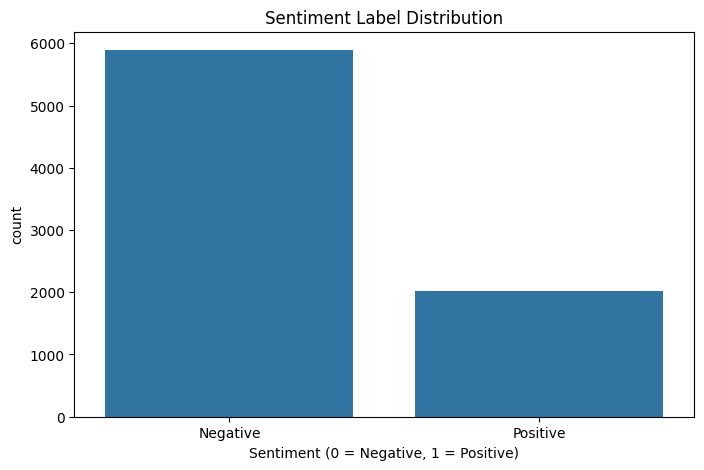

In [20]:
# Label distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label')
plt.title('Sentiment Label Distribution')
plt.xlabel('Sentiment (0 = Negative, 1 = Positive)')
plt.xticks(ticks=[0, 1], labels=['Negative', 'Positive'])
plt.show()

---
## 3. Text Preprocessing

In [ ]:
# === Download NLTK resources & preprocess ===
download_nltk_resources()

df = preprocess_dataframe(df, text_col='text', output_col='cleaned_text')

print("Sample cleaned text:")
df[['text', 'cleaned_text']].head(10)

In [ ]:
# === Train/Test Split ===
X = df['cleaned_text'].tolist()
y = df['sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

---
## 4. Feature Extraction

In [ ]:
fe = FeatureExtractor(max_tfidf_features=5000)

### 4.1 TF-IDF Features

In [ ]:
X_train_tfidf = fe.extract_tfidf(X_train, fit=True)
X_test_tfidf = fe.extract_tfidf(X_test, fit=False)

print(f"TF-IDF Train shape: {X_train_tfidf.shape}")
print(f"TF-IDF Test shape:  {X_test_tfidf.shape}")

### 4.2 DistilBERT Embeddings

In [ ]:
X_train_bert = fe.extract_bert(X_train, batch_size=64)
X_test_bert = fe.extract_bert(X_test, batch_size=64)

print(f"BERT Train shape: {X_train_bert.shape}")
print(f"BERT Test shape:  {X_test_bert.shape}")

In [ ]:
# === Save extracted features ===
save_features(X_train_bert, 'features/X_train_bert.npy')
save_features(X_test_bert, 'features/X_test_bert.npy')
save_features(y_train, 'features/y_train.npy')
save_features(y_test, 'features/y_test.npy')

print("\n✅ All features saved!")

---
## 5. Model Training & Evaluation

### 5.1 Traditional ML Models (TF-IDF)

In [ ]:
traditional = TraditionalModels()
models = traditional.get_models()
results_traditional = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)
    result = traditional.train_evaluate(
        model, X_train_tfidf, X_test_tfidf, y_train, y_test
    )
    results_traditional[name] = result
    print(f"Accuracy: {result['accuracy']:.4f}")
    print(result['report'])

In [ ]:
# === Confusion Matrices for Traditional Models ===
labels = ['Negative', 'Positive']

for name, result in results_traditional.items():
    plot_confusion_matrix(
        y_test, result['y_pred'],
        labels=labels,
        title=f"{name} — Confusion Matrix",
        save_path=f"reports/{name.replace(' ', '_').lower()}_cm.png"
    )

### 5.2 Simple Neural Network (BERT Embeddings)

In [ ]:
# === (Optional) Load saved features instead of re-extracting ===
# X_train_bert = load_features('features/X_train_bert.npy')
# X_test_bert = load_features('features/X_test_bert.npy')
# y_train = load_features('features/y_train.npy')
# y_test = load_features('features/y_test.npy')

In [ ]:
# === Initialize and train the MLP ===
INPUT_DIM = X_train_bert.shape[1]  # 768 for DistilBERT
NUM_CLASSES = len(np.unique(y_train))

nn_model = SimpleNN(input_dim=INPUT_DIM, hidden_dim=256, num_classes=NUM_CLASSES)
print(nn_model)

nn_result = train_nn(
    model=nn_model,
    X_train=X_train_bert,
    y_train=y_train,
    X_test=X_test_bert,
    y_test=y_test,
    epochs=20,
    batch_size=64,
    learning_rate=1e-3,
)

print(f"\n🎯 SimpleNN Accuracy: {nn_result['accuracy']:.4f}")
print(nn_result['report'])

In [ ]:
# === Loss Curve ===
plot_loss_curve(
    nn_result['train_losses'],
    nn_result['val_losses'],
    title='SimpleNN — Training & Validation Loss',
    save_path='reports/nn_loss_curve.png'
)

# === Confusion Matrix ===
plot_confusion_matrix(
    y_test, nn_result['y_pred'],
    labels=labels,
    title='SimpleNN (BERT) — Confusion Matrix',
    save_path='reports/simplenn_cm.png'
)

---
## 6. Results Comparison

In [ ]:
# === Summary Table ===
summary = []
for name, result in results_traditional.items():
    summary.append({'Model': name, 'Features': 'TF-IDF', 'Accuracy': result['accuracy']})

summary.append({'Model': 'SimpleNN (MLP)', 'Features': 'DistilBERT', 'Accuracy': nn_result['accuracy']})

results_df = pd.DataFrame(summary).sort_values('Accuracy', ascending=False)
results_df.style.highlight_max(subset=['Accuracy'], color='lightgreen')

In [ ]:
print("\n✅ Pipeline complete! Check the 'reports/' folder for saved figures.")